customerID: A unique ID that identifies each customer.

gender: The customer’s gender: Male, Female.

SeniorCitizen: Indicates if the customer is 65 or older: Yes, No.

Partner: Indicates if the customer has any partners: Yes, No.

Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

tenure: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

PhoneService: Indicates if the customer subscribes to home phone service with the company: Yes, No.

MultipleLines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No.

InternetService: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

OnlineSecurity: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No.

OnlineBackup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No.

DeviceProtection: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No.

TechSupport: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No.

StreamingTV: Indicates if the customer uses their Internet service to stream television programming from a third-party provider: Yes, No. The company does not charge an additional fee for this service.

StreamingMovies: Indicates if the customer uses their Internet service to stream movies from a third-party provider: Yes, No. The company does not charge an additional fee for this service.

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

PaperlessBilling: Indicates if the customer has chosen paperless billing: Yes, No.

PaymentMethod: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check.

MonthlyCharges: Indicates the customer’s current total monthly charge for all their services from the company.

TotalCharges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Churn: Indicates if the customer left within the last month: Yes, No.

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, RFECV, SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [103]:
df = pd.read_csv('dataset.csv')

In [104]:
df.shape

(7043, 21)

In [105]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [106]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [107]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [108]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [109]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').astype('float64')

In [110]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [111]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [112]:
df[df['tenure'] == 0].index

Int64Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [113]:
df = df.dropna(subset=['TotalCharges'])
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [114]:
demographic_column_names = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
							 
service_column_names = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
						'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
				
categorical_account_column_names = ['Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

categorical_account_column_names_without_churn = ['Contract', 'PaperlessBilling', 'PaymentMethod']

numerical_account_column_names = ['tenure', 'MonthlyCharges', 'TotalCharges']


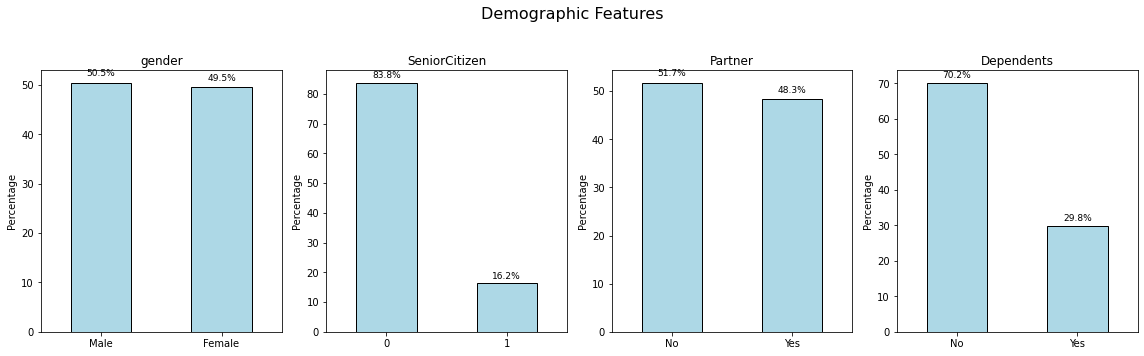

In [115]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Demographic Features", fontsize=16)

for i, column in enumerate(demographic_column_names):
    counts = df[column].value_counts(normalize=True) * 100
    ax = counts.plot(kind='bar', color='lightblue', edgecolor='black', ax=axes[i])

    ax.set_title(f'{column}')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    for j, percentage in enumerate(counts):
        ax.text(j, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

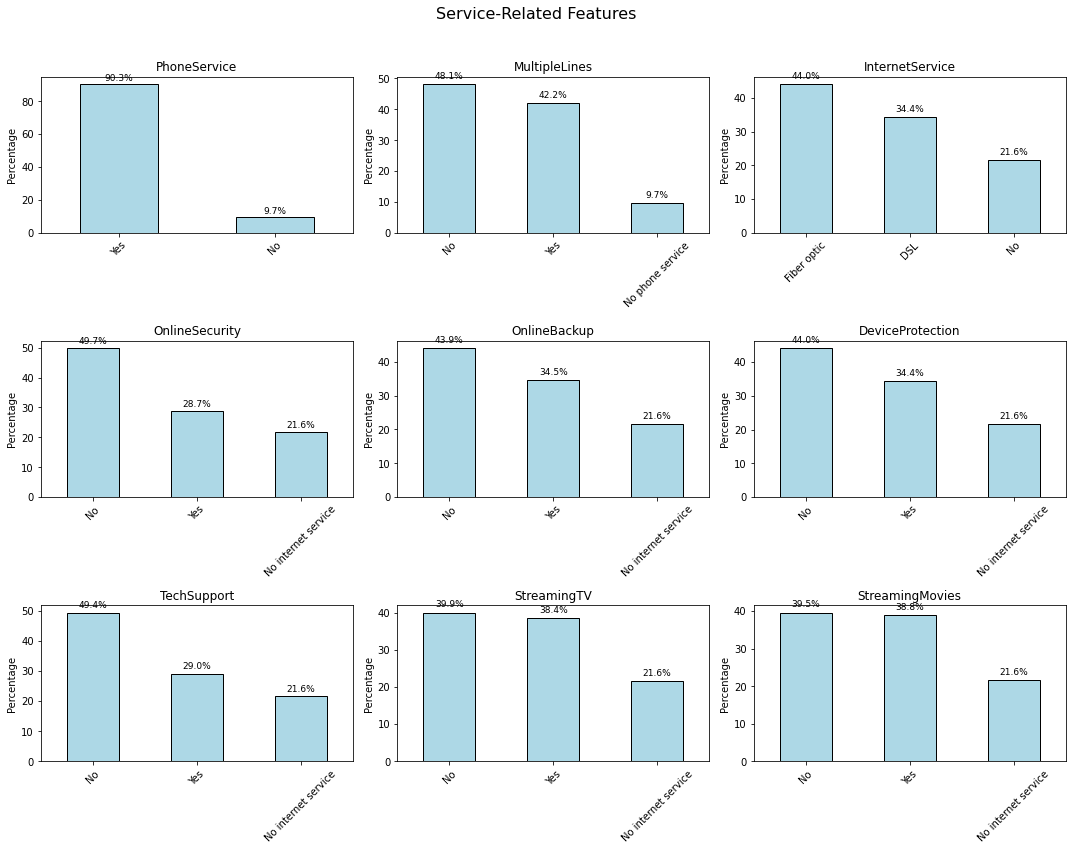

In [116]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Service-Related Features", fontsize=16)

for i, column in enumerate(service_column_names):
    row, col = divmod(i, 3)
    counts = df[column].value_counts(normalize=True) * 100
    ax = counts.plot(kind='bar', color='lightblue', edgecolor='black', ax=axes[row, col])
    
    ax.set_title(f'{column}')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    for j, percentage in enumerate(counts):
        ax.text(j, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/var/folders/bt/h2dw0hxn3nv1hk7nj1gqmsw00000gn/T/ipykernel_5282/4287062975.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


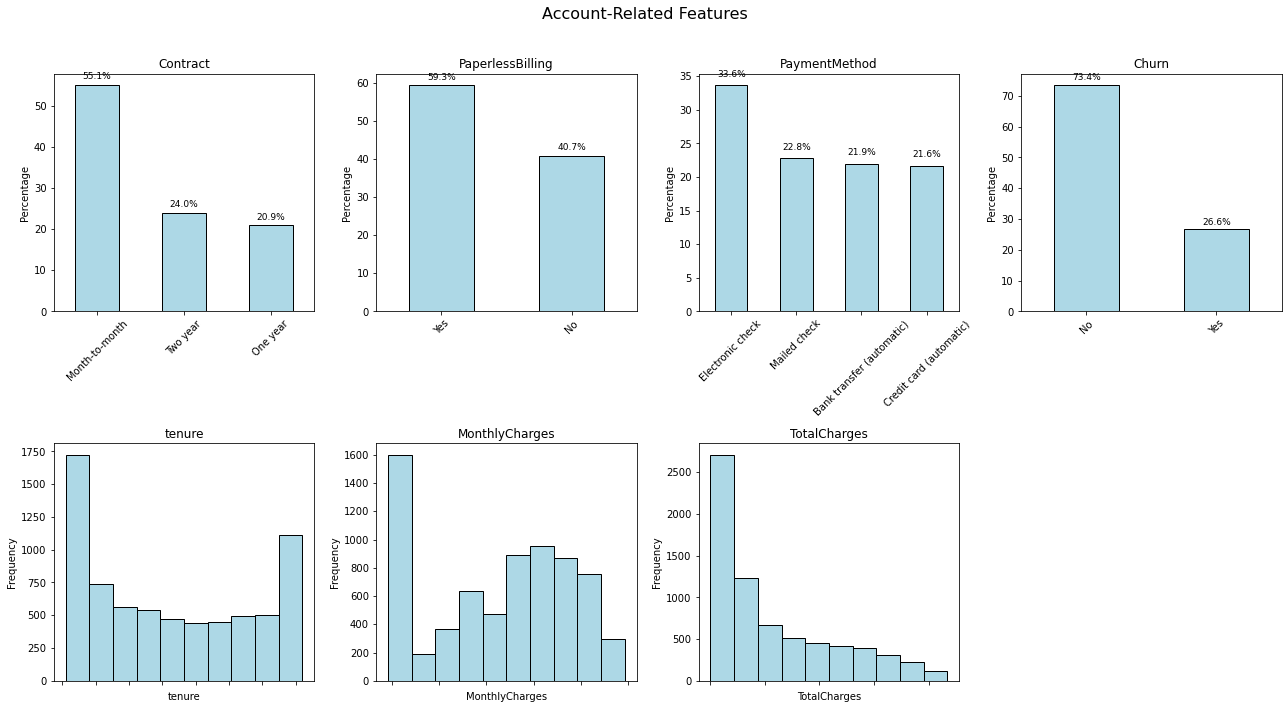

In [117]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Account-Related Features", fontsize=16)

for i, column in enumerate(categorical_account_column_names):
    counts = df[column].value_counts(normalize=True) * 100
    ax = counts.plot(kind='bar', color='lightblue', edgecolor='black', ax=axes[0, i])
    
    ax.set_title(f'{column}')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage')
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    for j, percentage in enumerate(counts):
        ax.text(j, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

for i, column in enumerate(numerical_account_column_names):
    ax = df[column].plot(kind='hist', bins=10, color='lightblue', edgecolor='black', ax=axes[1, i])
    ax.set_title(f'{column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

axes[1, 3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



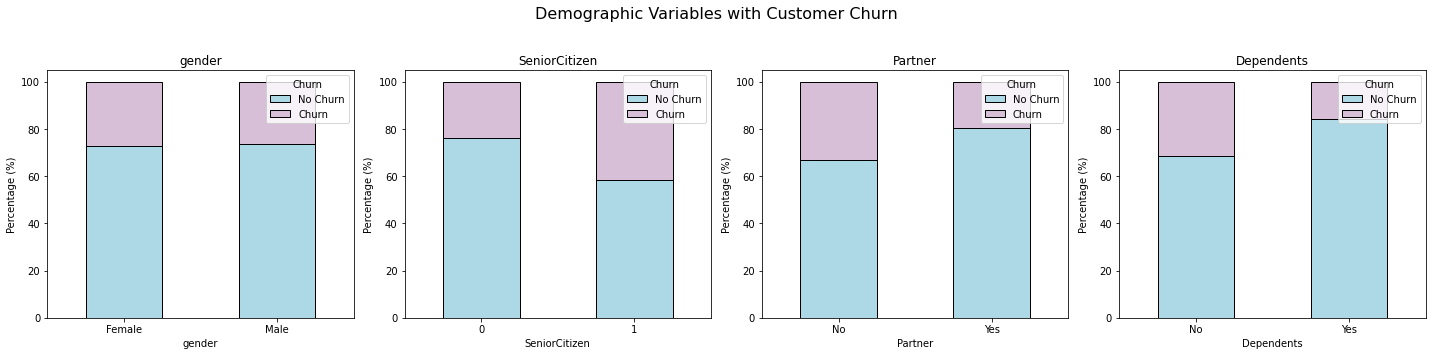

In [118]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Demographic Variables with Customer Churn", fontsize=16)

for i, column in enumerate(demographic_column_names):
    churn_counts = df.groupby(column)['Churn'].value_counts(normalize=True).unstack() * 100
    churn_counts.plot(kind='bar', stacked=True, color=['lightblue', 'thistle'], edgecolor='black', ax=axes[i])
    axes[i].set_title(f'{column}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Churn', labels=['No Churn', 'Churn'], loc='upper right')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

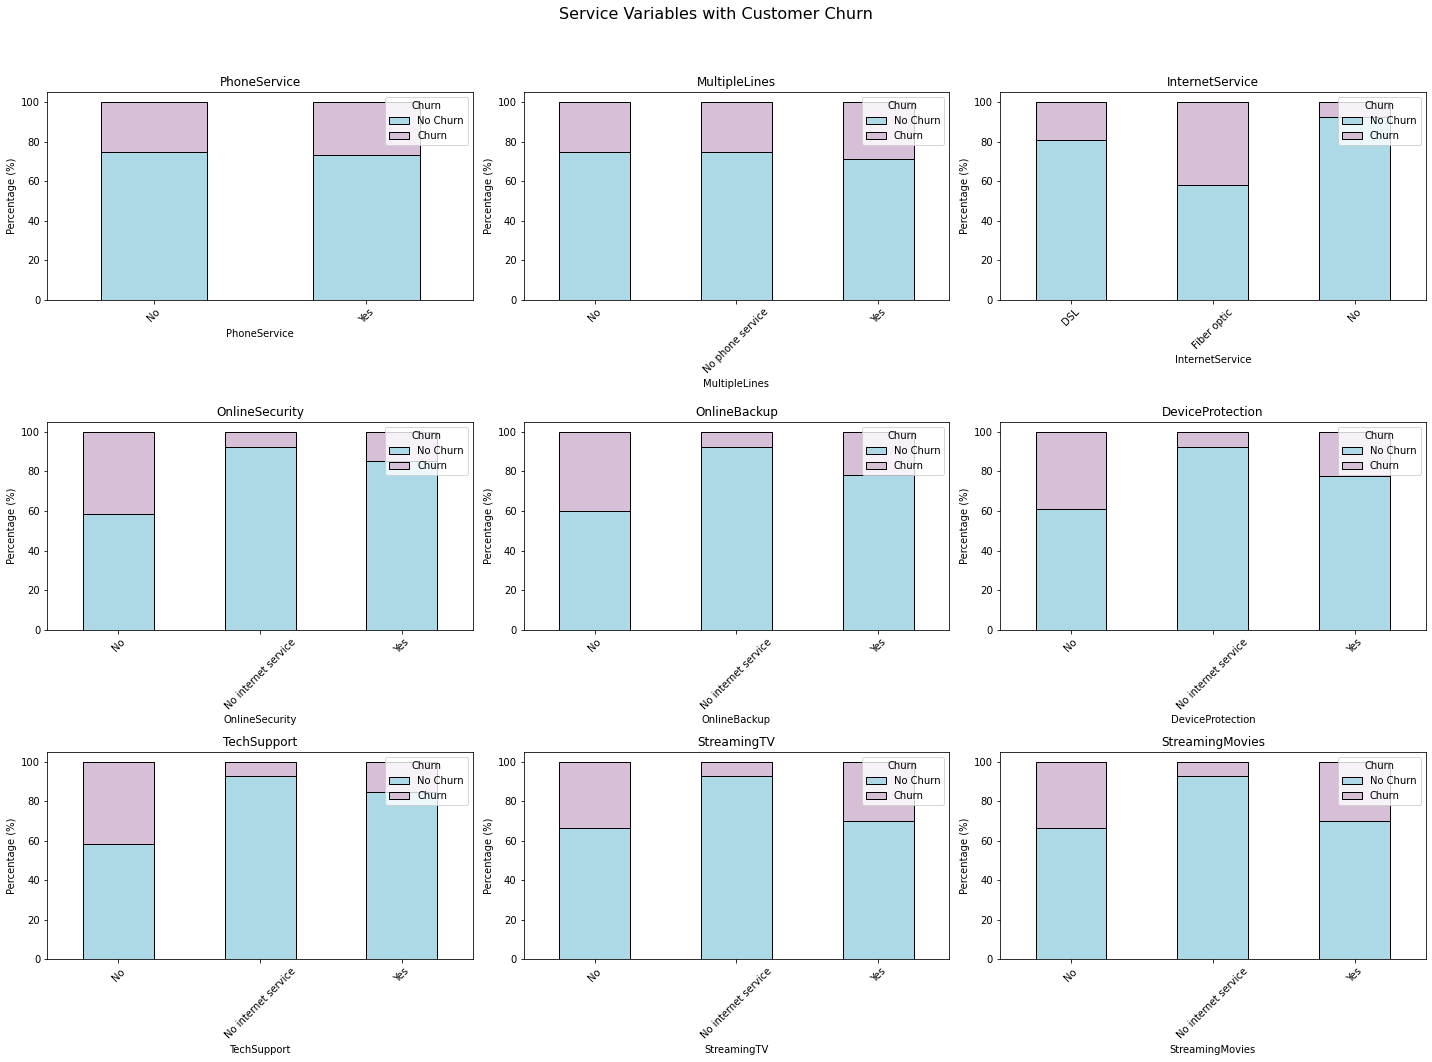

In [119]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("Service Variables with Customer Churn", fontsize=16)

for i, column in enumerate(service_column_names):
    row, col = divmod(i, 3)
    churn_counts = df.groupby(column)['Churn'].value_counts(normalize=True).unstack() * 100
    churn_counts.plot(kind='bar', stacked=True, color=['lightblue', 'thistle'], edgecolor='black', ax=axes[row, col])
    axes[row, col].set_title(f'{column}')
    axes[row, col].set_ylabel('Percentage (%)')
    axes[row, col].legend(title='Churn', labels=['No Churn', 'Churn'], loc='upper right')
    axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

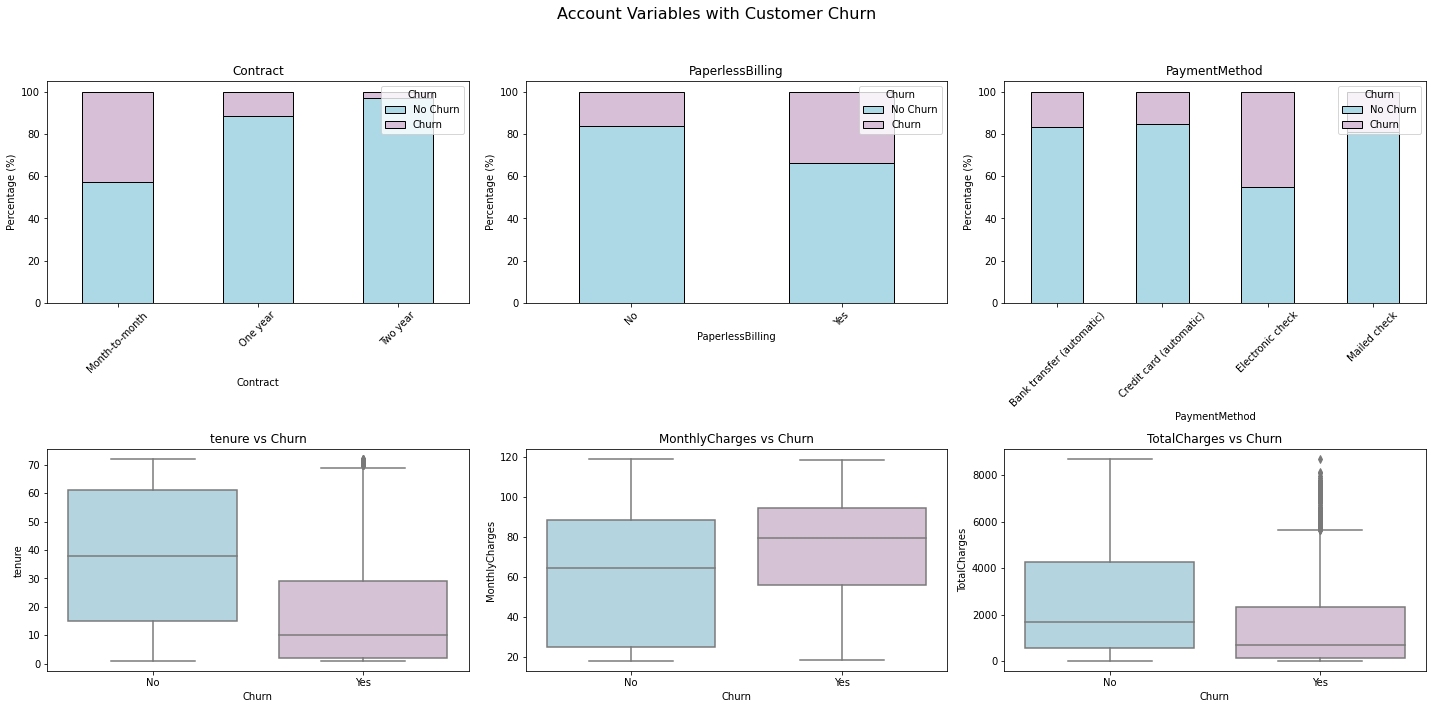

In [120]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Account Variables with Customer Churn", fontsize=16)

for i, column in enumerate(categorical_account_column_names_without_churn):
    churn_counts = df.groupby(column)['Churn'].value_counts(normalize=True).unstack() * 100
    churn_counts.plot(kind='bar', stacked=True, color=['lightblue', 'thistle'], edgecolor='black', ax=axes[0, i])
    axes[0, i].set_title(f'{column}')
    axes[0, i].set_ylabel('Percentage (%)')
    axes[0, i].legend(title='Churn', labels=['No Churn', 'Churn'], loc='upper right')
    axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=45)

for i, column in enumerate(numerical_account_column_names):
    sns.boxplot(x='Churn', y=column, data=df, ax=axes[1, i], palette=['lightblue', 'thistle'])
    axes[1, i].set_title(f'{column} vs Churn')
    axes[1, i].set_xlabel('Churn')
    axes[1, i].set_ylabel(column)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [121]:
categorical_columns = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]

for column in categorical_columns:
    df[column] = LabelEncoder().fit_transform(df[column])

In [122]:
df.dtypes

customerID           object
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [123]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1
5,9305-CDSKC,0,0,0,0,8,1,2,1,0,...,2,0,2,2,0,1,2,99.65,820.50,1
6,1452-KIOVK,1,0,0,1,22,1,2,1,0,...,0,0,2,0,0,1,1,89.10,1949.40,0
7,6713-OKOMC,0,0,0,0,10,0,1,0,2,...,0,0,0,0,0,0,3,29.75,301.90,0
8,7892-POOKP,0,0,1,0,28,1,2,1,0,...,2,2,2,2,0,1,2,104.80,3046.05,1
9,6388-TABGU,1,0,0,1,62,1,0,0,2,...,0,0,0,0,1,0,0,56.15,3487.95,0


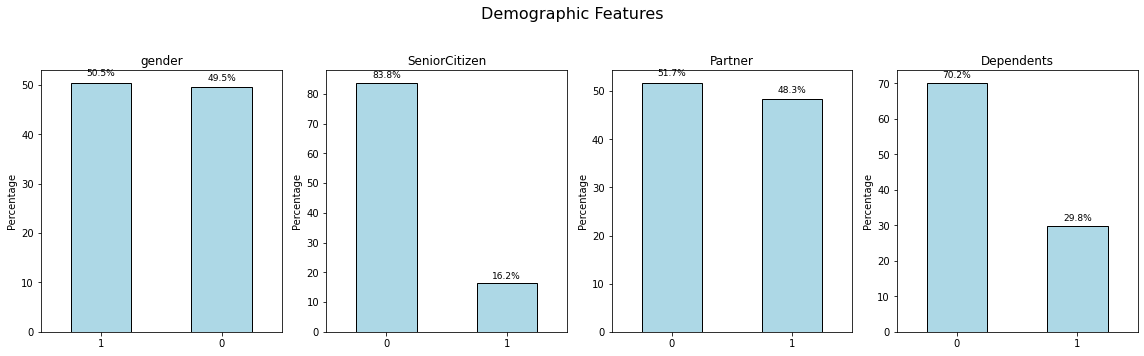

In [124]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Demographic Features", fontsize=16)

for i, column in enumerate(demographic_column_names):
    counts = df[column].value_counts(normalize=True) * 100
    ax = counts.plot(kind='bar', color='lightblue', edgecolor='black', ax=axes[i])

    ax.set_title(f'{column}')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    for j, percentage in enumerate(counts):
        ax.text(j, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

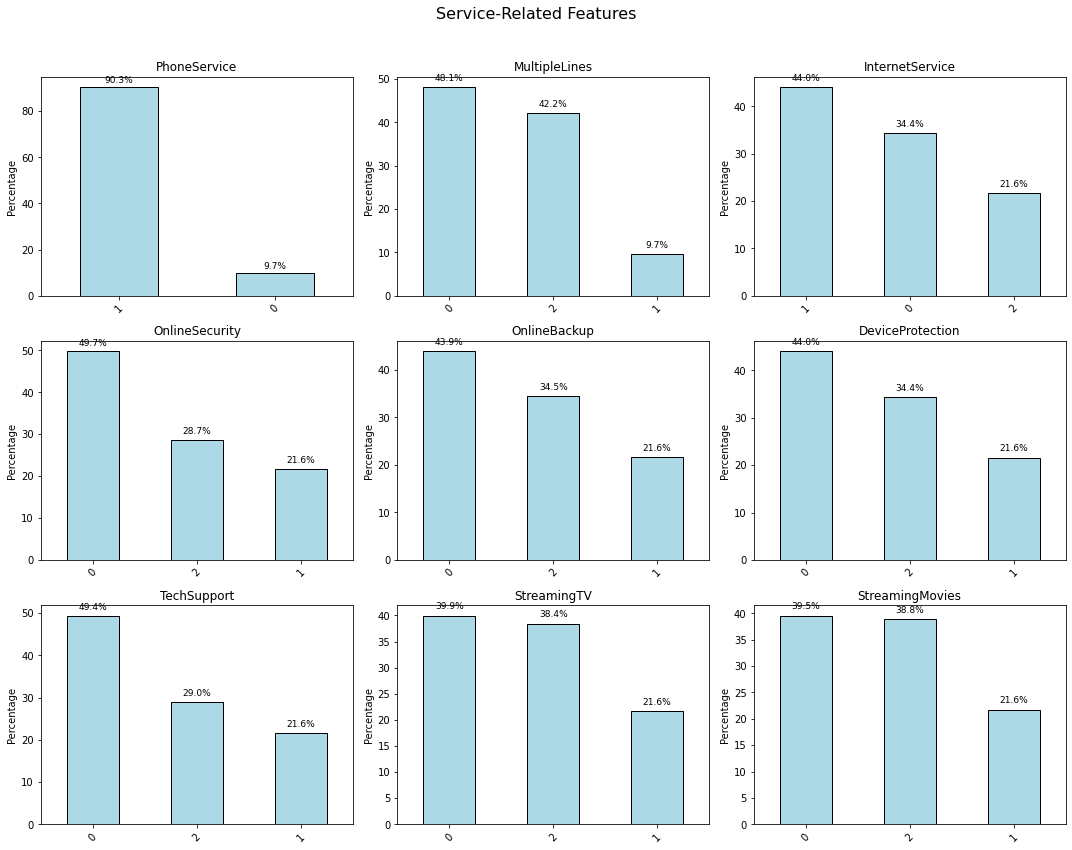

In [125]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Service-Related Features", fontsize=16)

for i, column in enumerate(service_column_names):
    row, col = divmod(i, 3)
    counts = df[column].value_counts(normalize=True) * 100
    ax = counts.plot(kind='bar', color='lightblue', edgecolor='black', ax=axes[row, col])
    
    ax.set_title(f'{column}')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    for j, percentage in enumerate(counts):
        ax.text(j, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/var/folders/bt/h2dw0hxn3nv1hk7nj1gqmsw00000gn/T/ipykernel_5282/2077039371.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


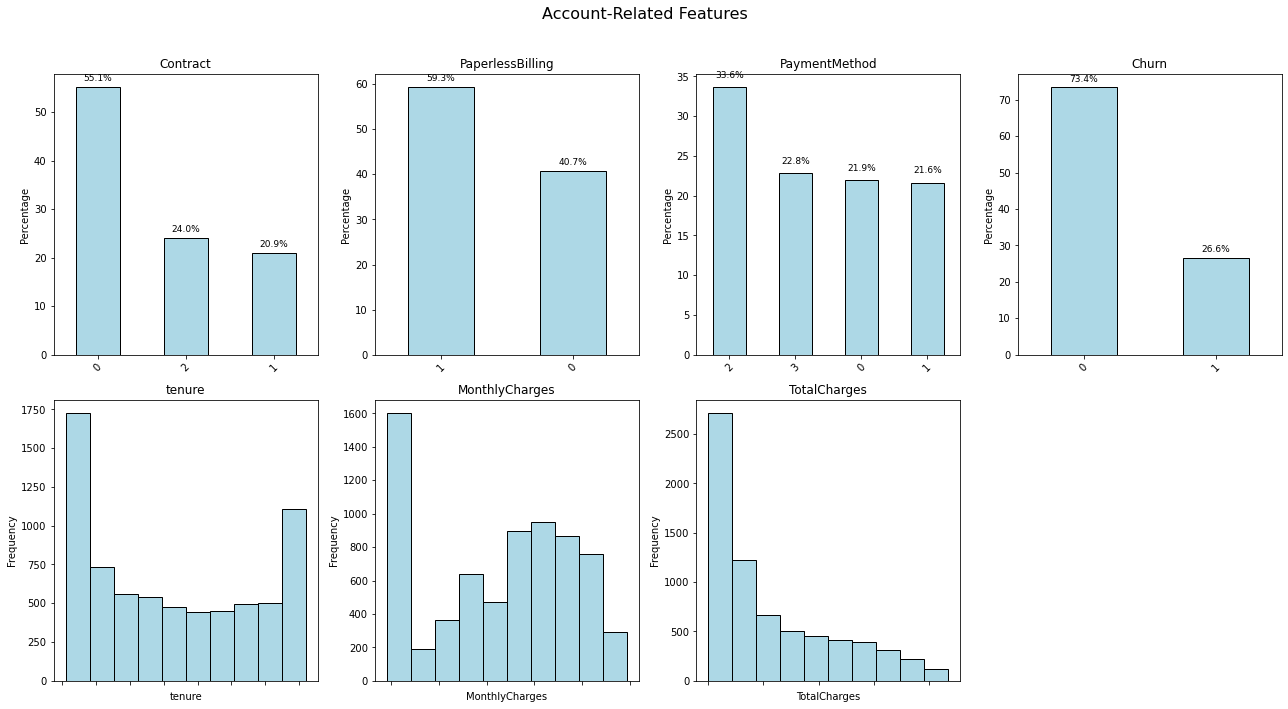

In [126]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Account-Related Features", fontsize=16)

for i, column in enumerate(categorical_account_column_names):
    counts = df[column].value_counts(normalize=True) * 100
    ax = counts.plot(kind='bar', color='lightblue', edgecolor='black', ax=axes[0, i])
    
    ax.set_title(f'{column}')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage')
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    for j, percentage in enumerate(counts):
        ax.text(j, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

for i, column in enumerate(numerical_account_column_names):
    ax = df[column].plot(kind='hist', bins=10, color='lightblue', edgecolor='black', ax=axes[1, i])
    ax.set_title(f'{column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

axes[1, 3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [127]:
df = df.drop(columns=['customerID'])
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
5,0,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
6,1,0,0,1,22,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1949.40,0
7,0,0,0,0,10,0,1,0,2,0,0,0,0,0,0,0,3,29.75,301.90,0
8,0,0,1,0,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
9,1,0,0,1,62,1,0,0,2,2,0,0,0,0,1,0,0,56.15,3487.95,0


In [128]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

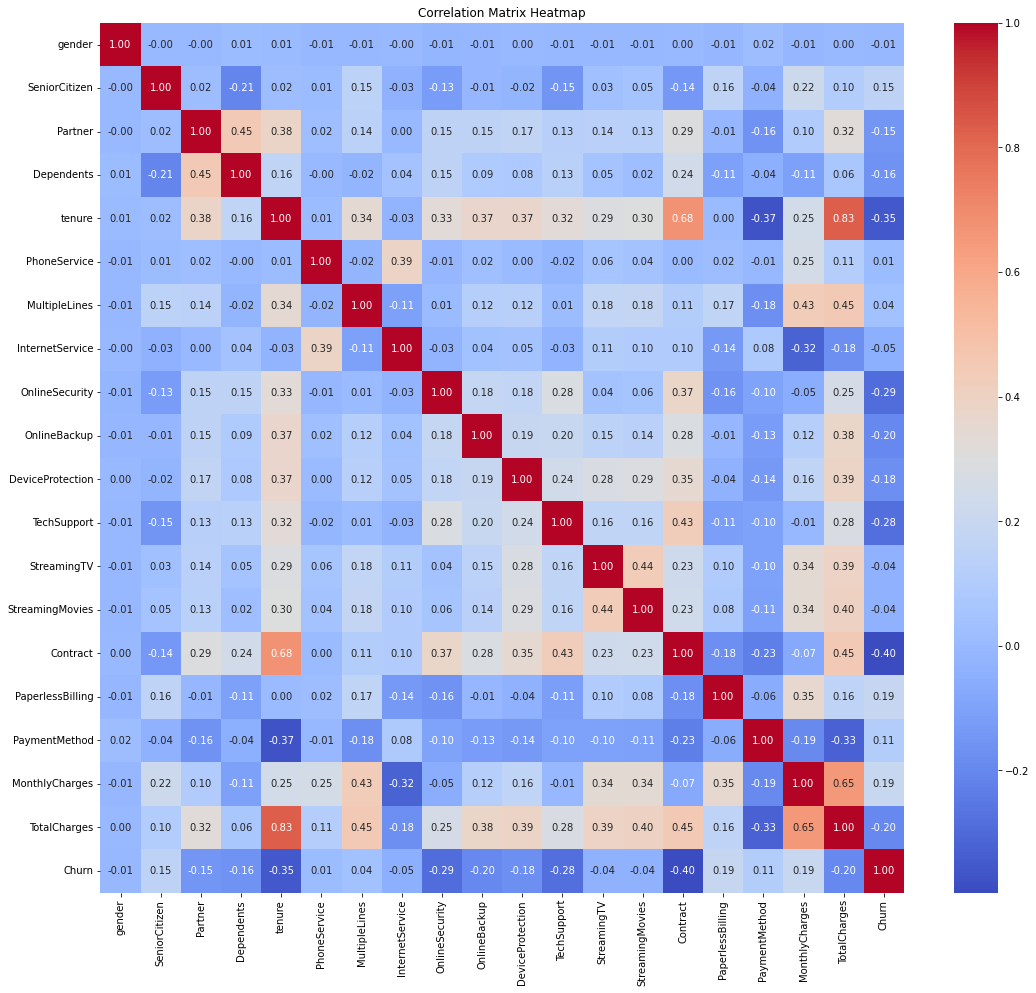

In [129]:
corr_matrix = df.corr()
plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [130]:
X = add_constant(df)
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data)

            Variable        VIF
0              const  35.129449
1             gender   1.001903
2      SeniorCitizen   1.152057
3            Partner   1.461176
4         Dependents   1.380561
5             tenure   7.505702
6       PhoneService   1.634125
7      MultipleLines   1.397391
8    InternetService   1.834546
9     OnlineSecurity   1.277858
10      OnlineBackup   1.222208
11  DeviceProtection   1.299523
12       TechSupport   1.331273
13       StreamingTV   1.446949
14   StreamingMovies   1.447896
15          Contract   2.502216
16  PaperlessBilling   1.206865
17     PaymentMethod   1.186603
18    MonthlyCharges   5.185452
19      TotalCharges  10.715545
20             Churn   1.380016


Logistic Regression: class weights, oversampling

In [131]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
numerical_account_column_names = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_scaled[numerical_account_column_names] = scaler.fit_transform(X_train_scaled[numerical_account_column_names])
X_test_scaled[numerical_account_column_names] = scaler.transform(X_test_scaled[numerical_account_column_names])

With TotalCharges

In [132]:
log_reg = LogisticRegression(random_state=123)
log_reg_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.1, 1, 10, 50, 100, 1000],
    'solver': ['liblinear']
}
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled, y_train)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters for Logistic Regression:", log_reg_grid.best_params_)

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1041
           1       0.62      0.53      0.58       366

    accuracy                           0.80      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

Best Parameters for Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


In [133]:
log_reg = LogisticRegression(class_weight='balanced', random_state=123)
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled, y_train)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters for Logistic Regression:", log_reg_grid.best_params_)

log_reg_best = log_reg_grid.best_estimator_

coefficients = log_reg_best.coef_[0]
intercept = log_reg_best.intercept_[0]

if hasattr(X_train_scaled, 'columns'):
    feature_names = X_train_scaled.columns
else:
    feature_names = [f'Feature_{i}' for i in range(len(coefficients))]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print(coef_df)
print("Intercept:", intercept)

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1041
           1       0.51      0.82      0.63       366

    accuracy                           0.74      1407
   macro avg       0.71      0.77      0.72      1407
weighted avg       0.81      0.74      0.76      1407

Best Parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
             Feature  Coefficient
17    MonthlyCharges     0.717175
18      TotalCharges     0.344856
15  PaperlessBilling     0.326818
1      SeniorCitizen     0.269772
7    InternetService     0.127386
6      MultipleLines     0.083449
13   StreamingMovies     0.057934
16     PaymentMethod     0.048446
12       StreamingTV     0.035542
0             gender     0.007748
2            Partner    -0.006663
10  DeviceProtection    -0.082662
9       OnlineBackup    -0.114639
3         Dependents    -0.122974
11       TechSupport    -0.223203
8     OnlineSecurity    -0.231232
5  

In [134]:
smote = SMOTE(random_state=123)
X_train_scaled_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

log_reg = LogisticRegression(random_state=123)
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled_sm, y_train_sm)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters for Logistic Regression:", log_reg_grid.best_params_)

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1041
           1       0.52      0.81      0.63       366

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407

Best Parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [135]:
log_reg = LogisticRegression(class_weight='balanced', random_state=123)
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled_sm, y_train_sm)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters for Logistic Regression:", log_reg_grid.best_params_)

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1041
           1       0.52      0.81      0.63       366

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407

Best Parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


Without TotalCharges

In [136]:
X_train_scaled_drop = X_train_scaled.drop(['TotalCharges'], axis=1)
X_train_scaled_drop.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
3457,0,0,0,0,-1.273676,1,0,2,1,1,1,1,1,1,0,1,3,-1.508689
612,1,0,0,1,1.373390,1,0,2,1,1,1,1,1,1,2,0,3,-1.473855
589,1,0,1,1,1.577011,1,2,0,2,2,2,2,2,2,2,0,2,0.843392
2685,0,0,1,0,1.617735,1,2,1,2,2,2,0,2,0,2,0,0,1.183432
1549,1,0,0,0,-1.273676,1,0,0,0,0,0,0,0,0,0,1,3,-0.634537


In [137]:
X_test_scaled_drop = X_test_scaled.drop(['TotalCharges'], axis=1)
X_test_scaled_drop.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
1778,1,0,1,1,1.617735,1,2,2,1,1,1,1,1,1,2,0,1,-1.334522
5036,0,1,1,0,-0.662815,1,2,1,0,0,0,0,0,2,0,1,1,0.675860
1106,0,0,0,0,1.251218,1,2,1,0,2,0,0,2,2,2,0,0,1.077273
1665,0,0,0,0,-0.947883,1,2,1,0,0,0,0,0,0,0,1,2,0.393876
927,0,0,0,0,-0.784987,1,0,1,0,2,2,0,0,0,0,1,2,0.536527


In [138]:
X_train_scaled_sm_drop = X_train_scaled_sm.drop(['TotalCharges'], axis=1)
X_train_scaled_sm_drop.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,0,0,0,0,-1.273676,1,0,2,1,1,1,1,1,1,0,1,3,-1.508689
1,1,0,0,1,1.373390,1,0,2,1,1,1,1,1,1,2,0,3,-1.473855
2,1,0,1,1,1.577011,1,2,0,2,2,2,2,2,2,2,0,2,0.843392
3,0,0,1,0,1.617735,1,2,1,2,2,2,0,2,0,2,0,0,1.183432
4,1,0,0,0,-1.273676,1,0,0,0,0,0,0,0,0,0,1,3,-0.634537


In [139]:
log_reg = LogisticRegression(random_state=123)
log_reg_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.1, 1, 10, 50, 100, 1000],
    'solver': ['liblinear']
}
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled_drop, y_train)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled_drop)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters:", log_reg_grid.best_params_)

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1041
           1       0.62      0.54      0.58       366

    accuracy                           0.80      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


In [140]:
log_reg = LogisticRegression(class_weight='balanced', random_state=123)
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled_drop, y_train)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled_drop)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters:", log_reg_grid.best_params_)

              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1041
           1       0.50      0.82      0.62       366

    accuracy                           0.74      1407
   macro avg       0.71      0.77      0.71      1407
weighted avg       0.81      0.74      0.76      1407

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


In [141]:
log_reg = LogisticRegression(random_state=123)
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled_sm_drop, y_train_sm)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled_drop)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters:", log_reg_grid.best_params_)

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1041
           1       0.51      0.79      0.62       366

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


In [142]:
log_reg = LogisticRegression(class_weight='balanced', random_state=123)
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled_sm_drop, y_train_sm)

log_reg_best = log_reg_grid.best_estimator_
log_reg_pred = log_reg_best.predict(X_test_scaled_drop)

log_reg_report = classification_report(y_test, log_reg_pred)
print(log_reg_report)

print("Best Parameters:", log_reg_grid.best_params_)

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1041
           1       0.51      0.79      0.62       366

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


Decision tree: class weights, oversampling

In [143]:
smote = SMOTE(random_state=123)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1041
           1       0.59      0.54      0.56       366

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


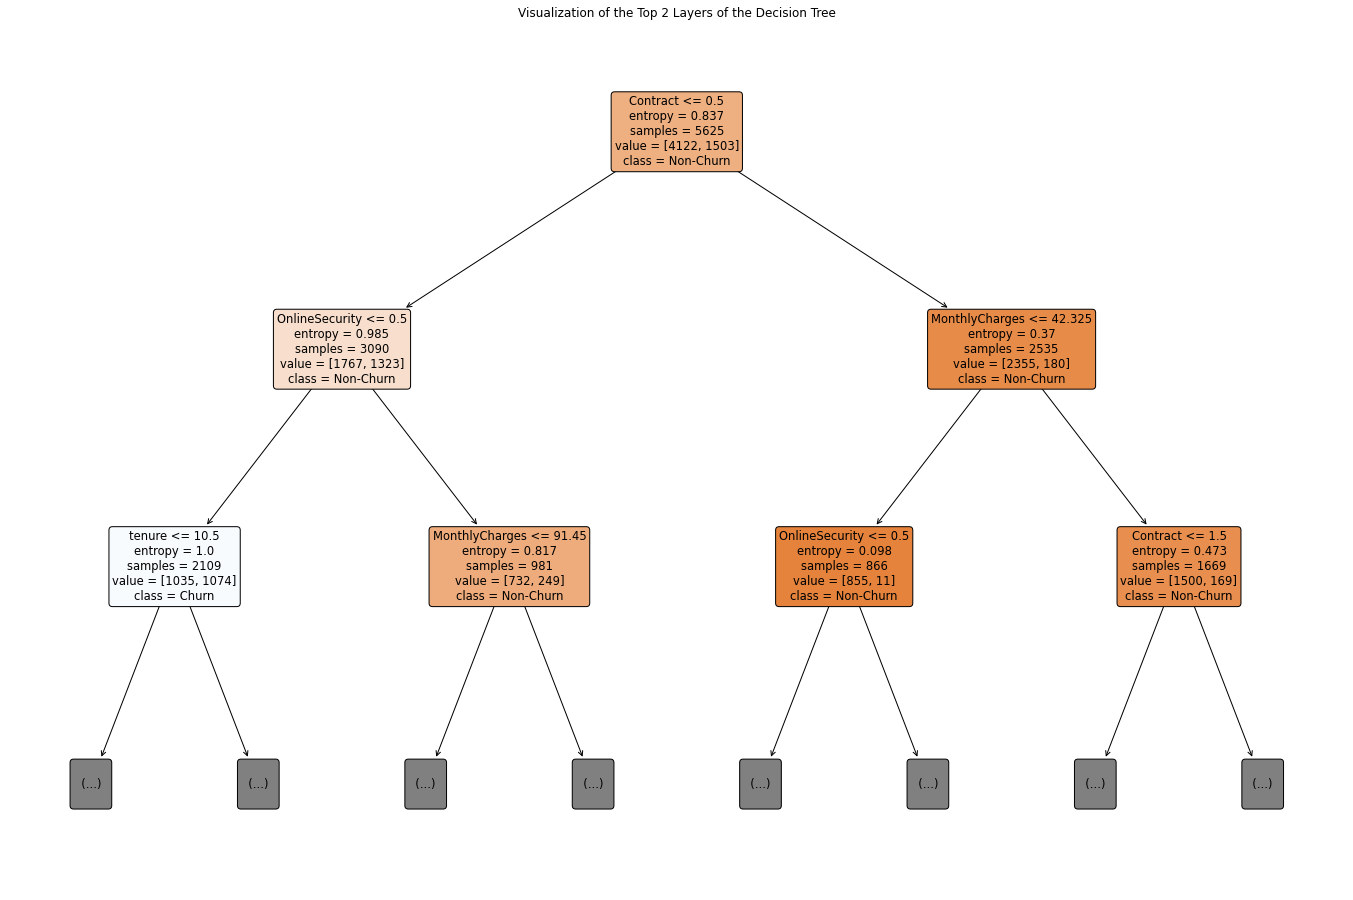

Index(['Contract', 'MonthlyCharges', 'TotalCharges', 'tenure',
       'OnlineSecurity', 'PaymentMethod', 'gender'],
      dtype='object')

In [144]:
dt = DecisionTreeClassifier(random_state=123)
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)

dt_report = classification_report(y_test, dt_pred)
print(dt_report)

print("Best Parameters:", dt_grid.best_params_)

plt.figure(figsize=(24, 16))
plot_tree(
    dt_best,
    max_depth=2,
    feature_names=X_train.columns,
    class_names=['Non-Churn', 'Churn'],
    filled=True,
    rounded=True
)
plt.title("Visualization of the Top 2 Layers of the Decision Tree")
plt.show()

feature_names = X_train.columns
importances = pd.Series(dt_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

              precision    recall  f1-score   support

           0       0.88      0.74      0.80      1041
           1       0.49      0.71      0.58       366

    accuracy                           0.73      1407
   macro avg       0.68      0.72      0.69      1407
weighted avg       0.78      0.73      0.74      1407

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


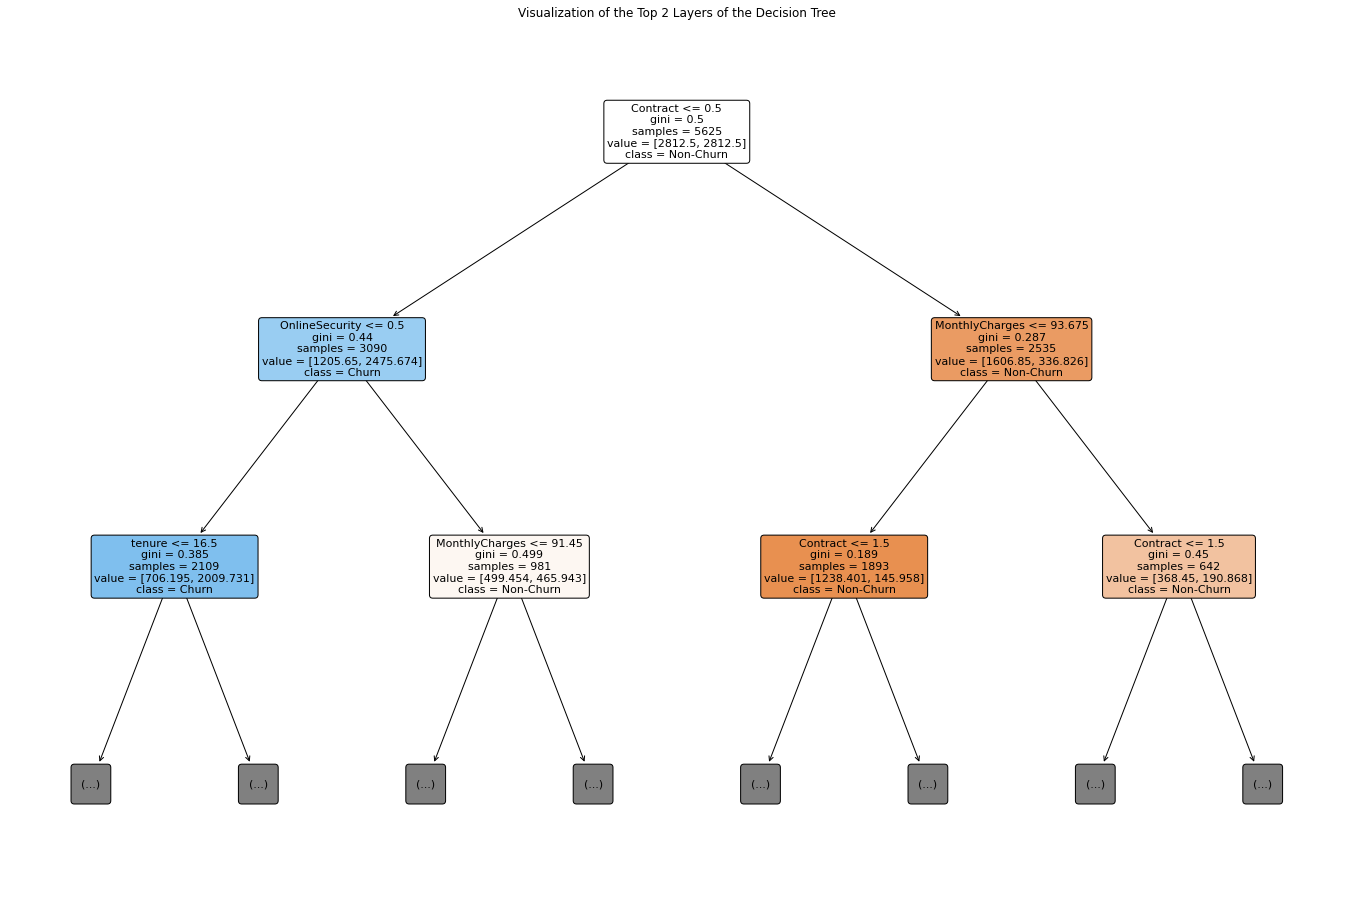

Index(['Contract', 'TotalCharges', 'MonthlyCharges', 'tenure',
       'OnlineSecurity', 'InternetService', 'PaymentMethod'],
      dtype='object')

In [145]:
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

dt = DecisionTreeClassifier(class_weight=class_weights, random_state=123)
dt.fit(X_train, y_train)

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)

dt_report = classification_report(y_test, dt_pred)
print(dt_report)

print("Best Parameters:", dt_grid.best_params_)

plt.figure(figsize=(24, 16))
plot_tree(
    dt_best,
    max_depth=2,
    feature_names=X_train_sm.columns,
    class_names=['Non-Churn', 'Churn'],
    filled=True,
    rounded=True
)
plt.title("Visualization of the Top 2 Layers of the Decision Tree")
plt.show()

feature_names = X_train.columns
importances = pd.Series(dt_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1041
           1       0.52      0.61      0.56       366

    accuracy                           0.75      1407
   macro avg       0.68      0.70      0.69      1407
weighted avg       0.76      0.75      0.76      1407

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


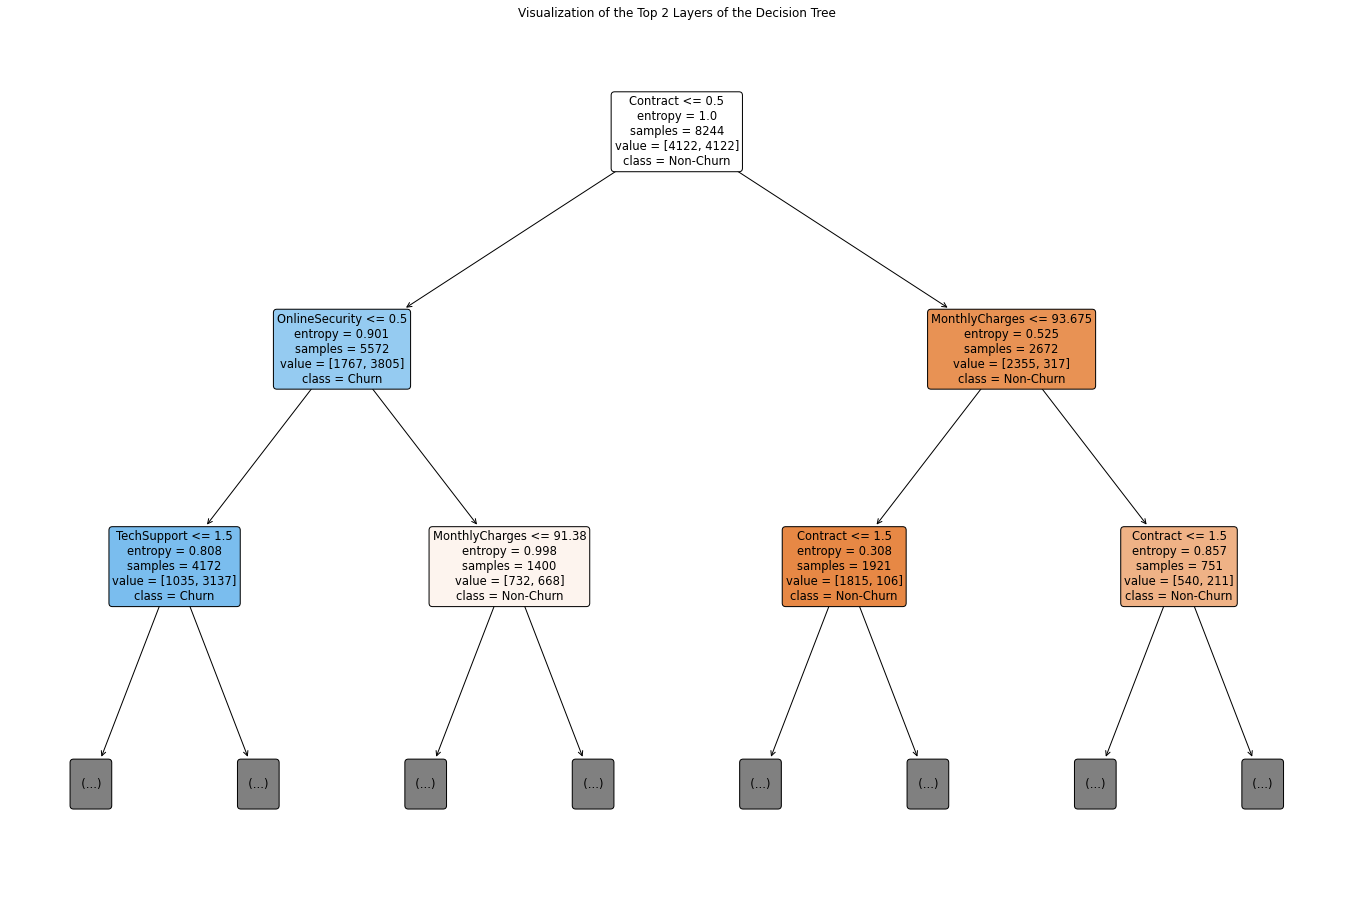

Index(['Contract', 'MonthlyCharges', 'TotalCharges', 'OnlineSecurity',
       'tenure', 'TechSupport', 'OnlineBackup'],
      dtype='object')

In [146]:
dt = DecisionTreeClassifier(random_state=123)
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train_sm, y_train_sm)

dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)

dt_report = classification_report(y_test, dt_pred)
print(dt_report)

print("Best Parameters:", dt_grid.best_params_)

plt.figure(figsize=(24, 16))
plot_tree(
    dt_best,
    max_depth=2,
    feature_names=X_train_sm.columns,
    class_names=['Non-Churn', 'Churn'],
    filled=True,
    rounded=True
)
plt.title("Visualization of the Top 2 Layers of the Decision Tree")
plt.show()

feature_names = X_train.columns
importances = pd.Series(dt_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1041
           1       0.52      0.61      0.56       366

    accuracy                           0.75      1407
   macro avg       0.68      0.70      0.69      1407
weighted avg       0.76      0.75      0.76      1407

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


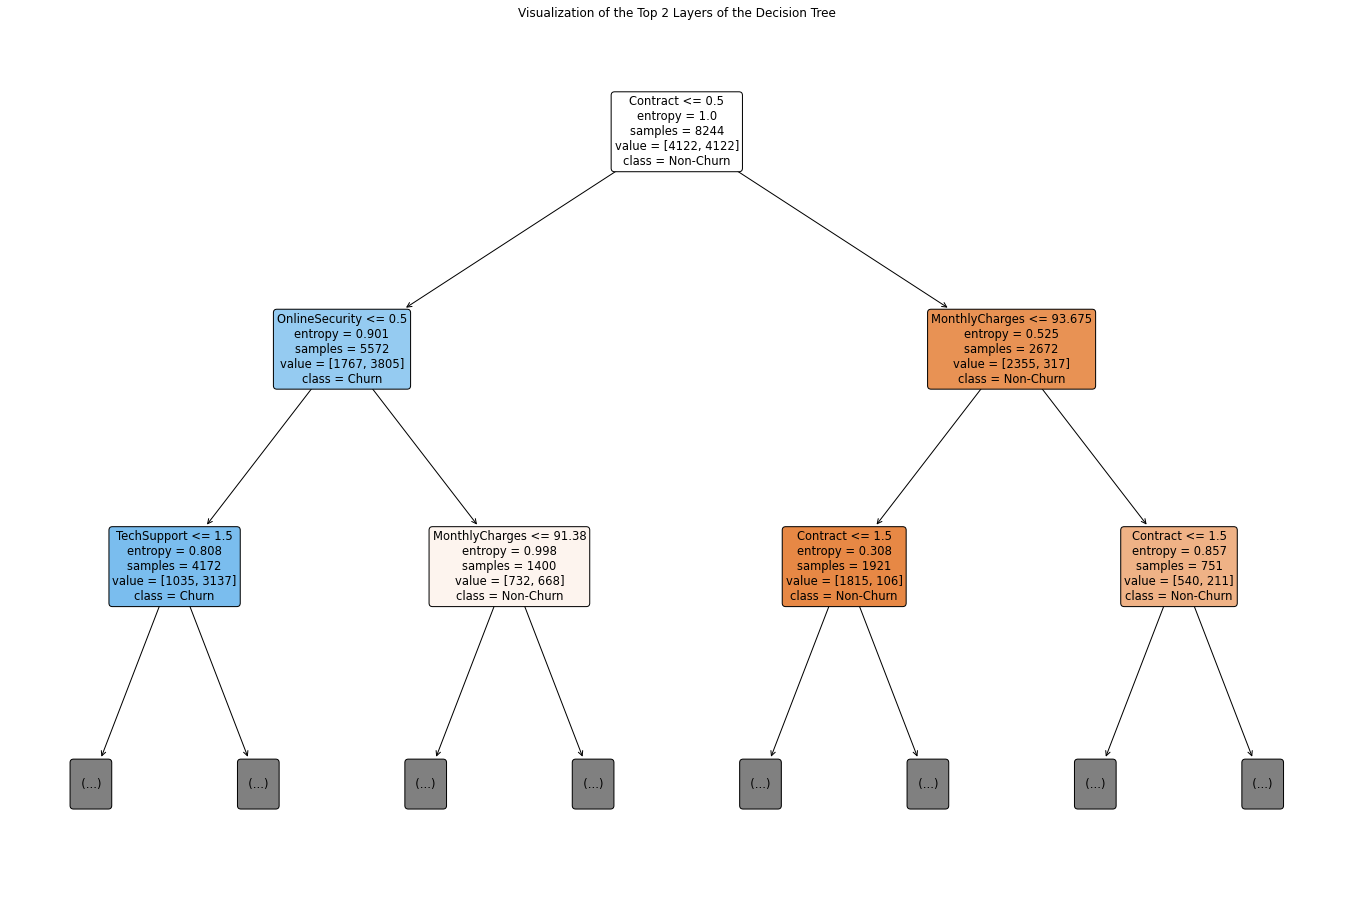

Index(['Contract', 'MonthlyCharges', 'TotalCharges', 'OnlineSecurity',
       'tenure', 'TechSupport', 'OnlineBackup'],
      dtype='object')

In [147]:
dt_class_weight = DecisionTreeClassifier(class_weight=class_weights, random_state=123)
dt_class_weight.fit(X_train_sm, y_train_sm)

dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)

dt_report = classification_report(y_test, dt_pred)
print(dt_report)

print("Best Parameters:", dt_grid.best_params_)

plt.figure(figsize=(24, 16))
plot_tree(
    dt_best,
    max_depth=2,
    feature_names=X_train_sm.columns,
    class_names=['Non-Churn', 'Churn'],
    filled=True,
    rounded=True
)
plt.title("Visualization of the Top 2 Layers of the Decision Tree")
plt.show()

feature_names = X_train.columns
importances = pd.Series(dt_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

Random forest: class weights, oversampling

In [148]:
rf = RandomForestClassifier(random_state=123)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_report = classification_report(y_test, rf_pred)
print(rf_report)

print("Best Parameters:", rf_grid.best_params_)

feature_names = X_train.columns
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1041
           1       0.65      0.48      0.55       366

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.79      1407

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


Index(['Contract', 'tenure', 'TotalCharges', 'MonthlyCharges', 'TechSupport',
       'OnlineSecurity', 'InternetService'],
      dtype='object')

In [149]:
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

rf = RandomForestClassifier(class_weight=class_weights, n_estimators=100, random_state=123)

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_report = classification_report(y_test, rf_pred)
print(rf_report)

print("Best Parameters:", rf_grid.best_params_)

feature_names = X_train.columns
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1041
           1       0.55      0.74      0.63       366

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


Index(['Contract', 'tenure', 'TotalCharges', 'MonthlyCharges', 'TechSupport',
       'OnlineSecurity', 'InternetService'],
      dtype='object')

In [150]:
rf = RandomForestClassifier(random_state=123)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_sm, y_train_sm)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_report = classification_report(y_test, rf_pred)
print(rf_report)

print("Best Parameters:", rf_grid.best_params_)

feature_names = X_train.columns
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1041
           1       0.57      0.68      0.62       366

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.73      1407
weighted avg       0.80      0.78      0.79      1407

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


Index(['Contract', 'TechSupport', 'OnlineSecurity', 'tenure', 'TotalCharges',
       'MonthlyCharges', 'InternetService'],
      dtype='object')

In [151]:
rf = RandomForestClassifier(class_weight=class_weights, n_estimators=100, random_state=123)

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_sm, y_train_sm)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_report = classification_report(y_test, rf_pred)
print(rf_report)

print("Best Parameters:", rf_grid.best_params_)

feature_names = X_train.columns
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(7).index

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1041
           1       0.54      0.73      0.62       366

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407

Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


Index(['Contract', 'MonthlyCharges', 'TotalCharges', 'tenure', 'TechSupport',
       'OnlineSecurity', 'PaymentMethod'],
      dtype='object')

XGBoost: scale_pos_weight, oversampling

In [152]:
xgb = XGBClassifier(eval_metric='logloss', random_state=123)

xgb_params = {
    "n_estimators": [50, 100, 150, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1', verbose=1, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

xgb_report = classification_report(y_test, xgb_pred)
print(xgb_report)

print("Best Parameters:", xgb_grid.best_params_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1041
           1       0.65      0.49      0.56       366

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.79      0.80      0.79      1407

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


In [153]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=123)

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1', verbose=1, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

xgb_report = classification_report(y_test, xgb_pred)
print(xgb_report)

print("Best Parameters:", xgb_grid.best_params_)


Fitting 5 folds for each of 240 candidates, totalling 1200 fits
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1041
           1       0.52      0.79      0.63       366

    accuracy                           0.75      1407
   macro avg       0.71      0.77      0.72      1407
weighted avg       0.81      0.75      0.77      1407

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0}


In [154]:
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1', verbose=1, n_jobs=-1)
xgb_grid.fit(X_train_sm, y_train_sm)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

xgb_report = classification_report(y_test, xgb_pred)
print(xgb_report)

print("Best Parameters:", xgb_grid.best_params_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
              precision    recall  f1-score   support

           0       0.86      0.79      0.83      1041
           1       0.52      0.65      0.58       366

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.78      0.75      0.76      1407

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}


In [155]:
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=123)

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1', verbose=1, n_jobs=-1)
xgb_grid.fit(X_train_sm, y_train_sm)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

xgb_report = classification_report(y_test, xgb_pred)
print(xgb_report)

print("Best Parameters:", xgb_grid.best_params_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
              precision    recall  f1-score   support

           0       0.86      0.79      0.83      1041
           1       0.52      0.65      0.58       366

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.78      0.75      0.76      1407

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}
